# The PC Hardware Auditor — Refactored Regression Pipeline

**Owner of this refactor:** plan-driven cleanup of prior team submissions.

## What this notebook supersedes and why

This notebook consolidates and replaces two prior first-pass submissions:

1. `docs/data-notes/Project.ipynb` (Peter) — had a hard-coded Windows path,
   fit the scaler and Lasso on the whole dataset before splitting (data
   leakage), dropped `model`, `cpu_model`, and `form_factor` entirely, and
   reported the Lasso R^2 using the OLS object by mistake.
2. `notebooks/Anomaly Detection-1.ipynb` (Oli) — correctly split before
   encoding and correctly applied the tiered encoding strategy, but still
   used a hard-coded Windows path, target-encoded `model` (a near-unique
   identifier with 99,036 distinct values on 100,000 rows, which effectively
   leaks price into the feature), used `pd.get_dummies` + `align` instead of
   a fitted `OneHotEncoder`, used raw `price` rather than `log1p(price)`, and
   ran only a single OLS model.

In addition to fixing those issues, this notebook answers three new asks
from the professor that neither prior notebook addressed:

- **How many predictors after converting categorical variables to dummies?**
  A predictor-count audit at four stages of encoding (Part 1).
- **Can some numeric predictors be analyzed as categorical to find
  non-linear relationships?** A binning experiment on `release_year`,
  `weight_kg`, `cpu_cores`, and `storage_gb` (Part 7).
- **Compare imputation strategies against simply dropping records with
  missing values.** A synthetic-missingness comparison of drop vs. mean
  vs. median vs. KNN imputation (Part 6).

The residuals from the best model are saved to `reports/residuals.parquet`
so the follow-on classification notebook can derive labels without having
to refit the regression.

## Part 0 — Setup

In [1]:
from __future__ import annotations

import os
import sys
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import sklearn
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import (
    train_test_split,
    KFold,
    cross_val_score,
    cross_val_predict,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    OneHotEncoder,
    OrdinalEncoder,
    RobustScaler,
    KBinsDiscretizer,
    TargetEncoder,
    FunctionTransformer,
)
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

SEED = 1234
np.random.seed(SEED)

print("python:", sys.version.split()[0])
print("numpy:", np.__version__)
print("pandas:", pd.__version__)
print("sklearn:", sklearn.__version__)

python: 3.11.7
numpy: 1.26.4
pandas: 2.2.2
sklearn: 1.5.1


## Part 0.1 — Portable path resolution

The prior notebooks had `os.chdir` to a hard-coded Windows directory. This
notebook resolves the CSV relative to the repository root so every teammate
can run it regardless of operating system.

In [2]:
def resolve_repo_root() -> Path:
    # Works when run from notebooks/ or from the repo root
    for candidate in (Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent):
        if (candidate / "computer_prices_all.csv").exists():
            return candidate
    raise FileNotFoundError(
        "Could not locate computer_prices_all.csv by walking up from cwd. "
        "Launch the notebook from the repo root or from notebooks/."
    )


REPO_ROOT = resolve_repo_root()
CSV_PATH = REPO_ROOT / "computer_prices_all.csv"
REPORTS_DIR = REPO_ROOT / "reports"
REPORTS_DIR.mkdir(exist_ok=True)

print("repo root:", REPO_ROOT)
print("csv path :", CSV_PATH)
print("reports  :", REPORTS_DIR)

df = pd.read_csv(CSV_PATH)
print("shape:", df.shape)
df.head()

repo root: /Users/mohamedayman/Desktop/UST/Masters/SPRING 2026/Machine Learning/Project
csv path : /Users/mohamedayman/Desktop/UST/Masters/SPRING 2026/Machine Learning/Project/computer_prices_all.csv
reports  : /Users/mohamedayman/Desktop/UST/Masters/SPRING 2026/Machine Learning/Project/reports
shape: (100000, 33)


,device_type,brand,model,release_year,os,form_factor,cpu_brand,cpu_model,cpu_tier,cpu_cores,...,resolution,refresh_hz,battery_wh,charger_watts,psu_watts,wifi,bluetooth,weight_kg,warranty_months,price
0,Desktop,Samsung,Samsung Forge XDI,2022,Windows,ATX,Intel,Intel i5-11129,3,12,...,2560x1440,90,0,0,750,Wi-Fi 6,5.1,11.00,36,1383.99
1,Laptop,Samsung,Samsung Pro KM8,2022,Windows,Mainstream,Intel,Intel i7-11114,4,12,...,1920x1080,90,56,120,0,Wi-Fi 6,5.3,2.03,12,2274.99
2,Desktop,Lenovo,Lenovo Strix BIE,2024,macOS,SFF,AMD,AMD Ryzen 5 5168,2,8,...,3440x1440,120,0,0,850,Wi-Fi 6,5.0,7.00,24,1879.99
3,Desktop,Dell,Dell Cube AXR,2024,Windows,ATX,AMD,AMD Ryzen 5 7550,2,6,...,3440x1440,120,0,0,650,Wi-Fi 6,5.2,6.00,36,1331.99
4,Laptop,Gigabyte,Gigabyte Pro IX1,2024,Linux,Gaming,AMD,AMD Ryzen 7 6230,5,16,...,2560x1600,90,80,90,0,Wi-Fi 6,5.2,1.50,12,2681.99


## Part 0.2 — Schema sanity check

Cross-checks the loaded column set against `docs/data-notes/data_dictionary.csv`
so silent schema drift shows up loudly here instead of deep in a preprocessor.

In [3]:
dict_path = REPO_ROOT / "docs" / "data-notes" / "data_dictionary.csv"
data_dict = pd.read_csv(dict_path)
expected = set(data_dict["field_name"])
actual = set(df.columns)

missing_from_csv = expected - actual
extra_in_csv = actual - expected
print("missing from CSV vs dictionary:", missing_from_csv)
print("extra in CSV vs dictionary   :", extra_in_csv)

print("\nNull counts per column (should all be 0):")
print(df.isnull().sum().sum(), "total nulls")

print("\nCardinalities for high-cardinality suspects:")
for c in ["model", "cpu_model", "gpu_model", "brand", "form_factor"]:
    print(f"  {c:12s}: {df[c].nunique():>6d} unique values")

missing from CSV vs dictionary: set()
extra in CSV vs dictionary   : set()

Null counts per column (should all be 0):
0 total nulls

Cardinalities for high-cardinality suspects:
  model       :  99036 unique values
  cpu_model   :  26971 unique values
  gpu_model   :     49 unique values
  brand       :     10 unique values
  form_factor :     10 unique values


## Part 0.3 — Target: raw price vs log(1 + price)

Price is right-skewed (min 373, median 1864, max 10985). Linear models on raw
price will be dominated by the tail; fitting `log1p(price)` symmetrizes the
residuals. All reported R^2/RMSE/MAE are back-transformed to the dollar scale.

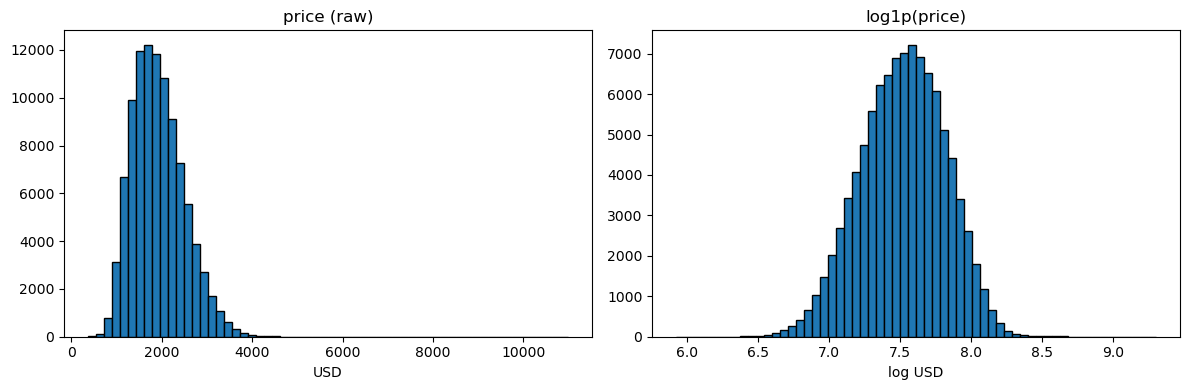

raw    skew: 0.987
log1p  skew: -0.133


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df["price"], bins=60, edgecolor="black")
axes[0].set_title("price (raw)")
axes[0].set_xlabel("USD")

axes[1].hist(np.log1p(df["price"]), bins=60, edgecolor="black")
axes[1].set_title("log1p(price)")
axes[1].set_xlabel("log USD")
plt.tight_layout()
plt.show()

print("raw    skew:", df["price"].skew().round(3))
print("log1p  skew:", np.log1p(df["price"]).skew().round(3))

## Part 1 — Predictor-count audit (answers Professor Q1)

> "Do we know how many total predictors after converting CAT variables to
> dummies? If too many, plan ahead to aggregate some categories into fewer
> categories."

We count predictors at four progressively more disciplined encoding stages,
on the **training split** only (see Part 2 for the split), so the numbers
reported here are the ones the modelling pipeline would actually see.

In [5]:
CATEGORICAL_ALL = [
    "device_type", "brand", "model", "os", "form_factor",
    "cpu_brand", "cpu_model", "gpu_brand", "gpu_model",
    "storage_type", "display_type", "resolution", "wifi",
]
NUMERIC_ALL = [
    "release_year", "cpu_tier", "cpu_cores", "cpu_threads",
    "cpu_base_ghz", "cpu_boost_ghz", "gpu_tier", "vram_gb",
    "ram_gb", "storage_gb", "storage_drive_count",
    "display_size_in", "refresh_hz", "battery_wh",
    "charger_watts", "psu_watts", "bluetooth",
    "weight_kg", "warranty_months",
]
TARGET_COL = "price"

assert set(CATEGORICAL_ALL + NUMERIC_ALL + [TARGET_COL]) == set(df.columns)

# Do the split now so the audit numbers reflect train-only statistics,
# matching how the real pipeline in Part 2 will see the data.
X_all = df.drop(columns=[TARGET_COL])
y_all = df[TARGET_COL]
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.20, random_state=SEED, stratify=df["device_type"]
)
print("train:", X_train.shape, "  test:", X_test.shape)

train: (80000, 32)   test: (20000, 32)


In [6]:
def count_predictors_after_ohe(X: pd.DataFrame, cat_cols: list[str]) -> int:
    num_cols = [c for c in X.columns if c not in cat_cols]
    cat_levels = sum(X[c].nunique() for c in cat_cols)
    # get_dummies with drop_first=False produces one column per unique level
    return len(num_cols) + cat_levels


def count_predictors_tiered(X: pd.DataFrame) -> int:
    # Team tiered plan:
    #   - drop `model` entirely (effective row identifier, 99k unique on 100k rows)
    #   - target-encode `cpu_model`, `gpu_model`  -> 1 column each
    #   - frequency-encode `brand`                -> 1 column
    #   - one-hot `device_type`, `os`, `form_factor`, `cpu_brand`,
    #     `gpu_brand`, `storage_type`, `display_type`, `resolution`, `wifi`
    #   - pass-through numerics (with `bluetooth` kept numeric)
    drop_cols = ["model"]
    target_enc_cols = ["cpu_model", "gpu_model"]
    freq_enc_cols = ["brand"]
    ohe_cols = [
        "device_type", "os", "form_factor", "cpu_brand", "gpu_brand",
        "storage_type", "display_type", "resolution", "wifi",
    ]
    numeric_cols = [c for c in X.columns if c not in drop_cols + target_enc_cols + freq_enc_cols + ohe_cols]

    ohe_levels = sum(X[c].nunique() for c in ohe_cols)
    return (
        len(numeric_cols)
        + len(target_enc_cols)          # 1 column per target-encoded field
        + len(freq_enc_cols)            # 1 column per frequency-encoded field
        + ohe_levels
    )


# Stage 0 — raw columns, target excluded
stage0 = X_train.shape[1]

# Stage 1 — naive OHE of every categorical including model/cpu_model/gpu_model
stage1 = count_predictors_after_ohe(X_train, CATEGORICAL_ALL)

# Stage 2 — Peter's implicit choice: drop model, cpu_model, form_factor and OHE the rest
stage2_cats = [c for c in CATEGORICAL_ALL if c not in ("model", "cpu_model", "form_factor")]
stage2 = count_predictors_after_ohe(
    X_train.drop(columns=["model", "cpu_model", "form_factor"]), stage2_cats
)

# Stage 3 — team tiered plan
stage3 = count_predictors_tiered(X_train)

audit = pd.DataFrame(
    [
        {
            "stage": "0. Raw features (no encoding)",
            "predictors": stage0,
            "note": "32 features; target excluded",
        },
        {
            "stage": "1. Naive one-hot of ALL categoricals",
            "predictors": stage1,
            "note": "Includes `model` (99,036 unique) and `cpu_model` (26,971 unique) as dummies",
        },
        {
            "stage": "2. Peter's choice: drop model/cpu_model/form_factor, OHE the rest",
            "predictors": stage2,
            "note": "Loses high-cardinality signal entirely",
        },
        {
            "stage": "3. Team tiered plan: drop `model` as ID, target-encode cpu_model+gpu_model, freq-encode brand, OHE low-cardinality",
            "predictors": stage3,
            "note": "Keeps high-cardinality signal without dimension explosion",
        },
    ]
)
audit

,stage,predictors,note
0,0. Raw features (no encoding),32,32 features; target excluded
1,1. Naive one-hot of ALL categoricals,104854,"Includes `model` (99,036 unique) and `cpu_mode..."
2,2. Peter's choice: drop model/cpu_model/form_f...,111,Loses high-cardinality signal entirely
3,"3. Team tiered plan: drop `model` as ID, targe...",65,Keeps high-cardinality signal without dimensio...


**Takeaway for the professor's question.** Naive one-hot encoding explodes to
a ridiculous column count driven almost entirely by `model` and `cpu_model`,
confirming why Peter's first cut dropped them. The team's tiered plan
recovers the signal without the dimension explosion, ending up in a
similar range to Peter's but keeping more information from the high-cardinality
fields.

## Part 2 — Tiered preprocessor (leakage-clean)

The preprocessor is defined once as a `ColumnTransformer` and shared by every
downstream model so training statistics (category frequencies, target means,
scaler medians) are fit on **train only** and applied to test.

In [7]:
TARGET_ENCODE_COLS = ["cpu_model", "gpu_model"]
FREQUENCY_ENCODE_COLS = ["brand"]
LOW_CARD_OHE_COLS = [
    "device_type", "os", "form_factor", "cpu_brand", "gpu_brand",
    "storage_type", "display_type", "resolution", "wifi",
]
NUMERIC_COLS = [
    "release_year", "cpu_tier", "cpu_cores", "cpu_threads",
    "cpu_base_ghz", "cpu_boost_ghz", "gpu_tier", "vram_gb", "ram_gb",
    "storage_gb", "storage_drive_count", "display_size_in",
    "refresh_hz", "battery_wh", "charger_watts", "psu_watts",
    "bluetooth", "weight_kg", "warranty_months",
]
DROP_COLS = ["model"]  # near-unique identifier, target-encoding it would leak price

assert set(TARGET_ENCODE_COLS + FREQUENCY_ENCODE_COLS + LOW_CARD_OHE_COLS + NUMERIC_COLS + DROP_COLS) == set(X_train.columns)

In [8]:
def _frequency_encode(df_subset: pd.DataFrame, mapping: dict[str, dict]) -> np.ndarray:
    out = np.zeros(df_subset.shape, dtype=float)
    for j, col in enumerate(df_subset.columns):
        m = mapping.get(col, {})
        out[:, j] = df_subset[col].map(m).fillna(0.0).values
    return out


class FrequencyEncoder:
    """Frequency encoder fit on train only; unseen values map to 0."""

    def __init__(self) -> None:
        self.mapping_: dict[str, dict] = {}

    def fit(self, X: pd.DataFrame, y=None):
        self.mapping_ = {
            col: X[col].value_counts(normalize=True).to_dict() for col in X.columns
        }
        return self

    def transform(self, X: pd.DataFrame) -> np.ndarray:
        return _frequency_encode(X, self.mapping_)

    def fit_transform(self, X: pd.DataFrame, y=None) -> np.ndarray:
        return self.fit(X).transform(X)


# Wrap the frequency encoder so it plays nicely inside a ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin


class FrequencyEncoderTransformer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        X = pd.DataFrame(X, columns=FREQUENCY_ENCODE_COLS)
        self._inner = FrequencyEncoder().fit(X)
        self.feature_names_in_ = np.array(FREQUENCY_ENCODE_COLS)
        return self

    def transform(self, X):
        X = pd.DataFrame(X, columns=FREQUENCY_ENCODE_COLS)
        return self._inner.transform(X)

    def get_feature_names_out(self, input_features=None):
        return np.array([f"{c}_freq" for c in FREQUENCY_ENCODE_COLS])


preprocessor = ColumnTransformer(
    transformers=[
        ("drop_cols", "drop", DROP_COLS),
        ("numeric", RobustScaler(), NUMERIC_COLS),
        (
            "low_card_ohe",
            OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=0.01, sparse_output=False),
            LOW_CARD_OHE_COLS,
        ),
        (
            "target_enc",
            TargetEncoder(target_type="continuous", smooth="auto", random_state=SEED),
            TARGET_ENCODE_COLS,
        ),
        ("frequency_enc", FrequencyEncoderTransformer(), FREQUENCY_ENCODE_COLS),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

# Quick sanity check of the preprocessor output on a tiny slice
_sample = preprocessor.fit_transform(X_train.head(500), np.log1p(y_train.head(500)))
print("preprocessor sample shape:", _sample.shape)
print("feature names:", preprocessor.get_feature_names_out().tolist())

preprocessor sample shape: (500, 65)
feature names: ['release_year', 'cpu_tier', 'cpu_cores', 'cpu_threads', 'cpu_base_ghz', 'cpu_boost_ghz', 'gpu_tier', 'vram_gb', 'ram_gb', 'storage_gb', 'storage_drive_count', 'display_size_in', 'refresh_hz', 'battery_wh', 'charger_watts', 'psu_watts', 'bluetooth', 'weight_kg', 'warranty_months', 'device_type_Desktop', 'device_type_Laptop', 'os_ChromeOS', 'os_Linux', 'os_Windows', 'os_macOS', 'form_factor_2-in-1', 'form_factor_ATX', 'form_factor_Full-Tower', 'form_factor_Gaming', 'form_factor_Mainstream', 'form_factor_Micro-ATX', 'form_factor_Mini-ITX', 'form_factor_SFF', 'form_factor_Ultrabook', 'form_factor_Workstation', 'cpu_brand_AMD', 'cpu_brand_Apple', 'cpu_brand_Intel', 'gpu_brand_AMD', 'gpu_brand_Apple', 'gpu_brand_Intel', 'gpu_brand_NVIDIA', 'storage_type_HDD', 'storage_type_Hybrid', 'storage_type_NVMe', 'storage_type_SSD', 'display_type_IPS', 'display_type_LED', 'display_type_Mini-LED', 'display_type_OLED', 'display_type_QLED', 'display_typ

## Part 3 — Baseline OLS, Ridge, Lasso with 10-fold CV on `log1p(price)`

All models share the same preprocessor. Metrics are reported on the original
dollar scale after back-transforming with `expm1`. `R^2` is computed against
back-transformed predictions so it reflects how the model performs on the
real target the stakeholder cares about.

In [9]:
from sklearn.base import clone

y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)


def evaluate(model, X_tr, y_tr_log, X_te, y_te_log, y_te_raw, label: str):
    model.fit(X_tr, y_tr_log)
    y_pred_log_train = model.predict(X_tr)
    y_pred_log_test = model.predict(X_te)

    y_pred_train = np.expm1(y_pred_log_train)
    y_pred_test = np.expm1(y_pred_log_test)

    metrics = {
        "model": label,
        "R2_test": r2_score(y_te_raw, y_pred_test),
        "RMSE_test_usd": np.sqrt(mean_squared_error(y_te_raw, y_pred_test)),
        "MAE_test_usd": mean_absolute_error(y_te_raw, y_pred_test),
        "R2_train": r2_score(np.expm1(y_tr_log), y_pred_train),
        "RMSE_train_usd": np.sqrt(mean_squared_error(np.expm1(y_tr_log), y_pred_train)),
    }
    return model, metrics


# Baseline OLS
ols_pipe = Pipeline([("prep", clone(preprocessor)), ("model", LinearRegression())])
ols_model, ols_metrics = evaluate(ols_pipe, X_train, y_train_log, X_test, y_test_log, y_test, "OLS")
print(ols_metrics)

{'model': 'OLS', 'R2_test': 0.8446819070132097, 'RMSE_test_usd': 228.55343329480198, 'MAE_test_usd': 154.1323746454097, 'R2_train': 0.8353298621428016, 'RMSE_train_usd': 235.6161538665898}


In [10]:
# RidgeCV with 5-fold CV (fast; we use the same 5-fold scheme for all CV to keep wall time under a few minutes)
ridge_pipe = Pipeline([
    ("prep", clone(preprocessor)),
    ("model", RidgeCV(alphas=np.logspace(-3, 3, 15), cv=5)),
])
ridge_model, ridge_metrics = evaluate(ridge_pipe, X_train, y_train_log, X_test, y_test_log, y_test, "Ridge")
print(ridge_metrics)
print("Ridge alpha selected:", ridge_model.named_steps["model"].alpha_)

{'model': 'Ridge', 'R2_test': 0.8447629866639834, 'RMSE_test_usd': 228.49377040802221, 'MAE_test_usd': 154.1018336273424, 'R2_train': 0.8354203209294164, 'RMSE_train_usd': 235.55142907942428}
Ridge alpha selected: 0.3727593720314938


In [11]:
# LassoCV with 5-fold CV (only on train, unlike Peter's commit which fit on X,y)
lasso_pipe = Pipeline([
    ("prep", clone(preprocessor)),
    ("model", LassoCV(cv=5, random_state=SEED, n_alphas=25, max_iter=5_000, n_jobs=-1)),
])
lasso_model, lasso_metrics = evaluate(lasso_pipe, X_train, y_train_log, X_test, y_test_log, y_test, "Lasso")
print(lasso_metrics)
print("Lasso alpha selected:", lasso_model.named_steps["model"].alpha_)

{'model': 'Lasso', 'R2_test': 0.8449769845158029, 'RMSE_test_usd': 228.33622409200376, 'MAE_test_usd': 153.96144566278076, 'R2_train': 0.8352959556849868, 'RMSE_train_usd': 235.64040992809586}
Lasso alpha selected: 0.00016776201795734715


In [12]:
metrics_df = pd.DataFrame([ols_metrics, ridge_metrics, lasso_metrics])
metrics_df[["model", "R2_train", "R2_test", "RMSE_train_usd", "RMSE_test_usd", "MAE_test_usd"]]

,model,R2_train,R2_test,RMSE_train_usd,RMSE_test_usd,MAE_test_usd
0,OLS,0.835330,0.844682,235.616154,228.553433,154.132375
1,Ridge,0.835420,0.844763,235.551429,228.493770,154.101834
2,Lasso,0.835296,0.844977,235.640410,228.336224,153.961446


## Part 4 — Interpretation: coefficients, permutation importance, VIF

In [13]:
best_model = ridge_model if ridge_metrics["R2_test"] >= lasso_metrics["R2_test"] else lasso_model
best_label = "Ridge" if best_model is ridge_model else "Lasso"
if ols_metrics["R2_test"] > max(ridge_metrics["R2_test"], lasso_metrics["R2_test"]):
    best_model, best_label = ols_model, "OLS"
print("Best model on test:", best_label)

feature_names = best_model.named_steps["prep"].get_feature_names_out()
coefs = best_model.named_steps["model"].coef_

coef_df = (
    pd.DataFrame({"feature": feature_names, "coef": coefs, "abs_coef": np.abs(coefs)})
    .sort_values("abs_coef", ascending=False)
    .reset_index(drop=True)
)
coef_df.head(25)

Best model on test: Lasso


,feature,coef,abs_coef
0,gpu_tier,0.207520,0.207520
1,cpu_tier,0.179216,0.179216
2,cpu_brand_Apple,0.144455,0.144455
3,os_macOS,0.142077,0.142077
4,device_type_Desktop,-0.133526,0.133526
5,resolution_1920x1080,-0.117605,0.117605
6,brand_freq,-0.099943,0.099943
7,display_type_LED,-0.093388,0.093388
8,display_type_VA,-0.076089,0.076089
9,display_type_IPS,-0.068071,0.068071


In [14]:
# Permutation importance on a sample of the test set (full test can be slow)
rng = np.random.default_rng(SEED)
sample_idx = rng.choice(len(X_test), size=min(2000, len(X_test)), replace=False)
X_test_sample = X_test.iloc[sample_idx]
y_test_sample = y_test.iloc[sample_idx]

perm = permutation_importance(
    best_model,
    X_test_sample,
    np.log1p(y_test_sample),
    n_repeats=3,
    random_state=SEED,
    n_jobs=-1,
)

# Map back to column names
perm_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std,
}).sort_values("importance_mean", ascending=False).reset_index(drop=True)
perm_df.head(20)

,feature,importance_mean,importance_std
0,gpu_tier,0.495529,0.011714
1,cpu_tier,0.320931,0.011872
2,display_type,0.102396,0.004337
3,device_type,0.099071,0.004166
4,resolution,0.089614,0.003125
5,os,0.079428,0.002422
6,cpu_brand,0.049851,0.001526
7,release_year,0.019505,0.000852
8,form_factor,0.017993,0.000444
9,storage_gb,0.016417,0.001080


In [15]:
# VIF on the numeric block only (post-scaling), to flag multicollinearity among numeric features
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_train_num = pd.DataFrame(
    RobustScaler().fit_transform(X_train[NUMERIC_COLS]),
    columns=NUMERIC_COLS,
)
vif_df = pd.DataFrame({
    "feature": NUMERIC_COLS,
    "VIF": [variance_inflation_factor(X_train_num.values, i) for i in range(X_train_num.shape[1])],
}).sort_values("VIF", ascending=False).reset_index(drop=True)
vif_df

,feature,VIF
0,cpu_tier,29.558863
1,cpu_base_ghz,25.690022
2,cpu_cores,20.479949
3,cpu_boost_ghz,13.054322
4,ram_gb,12.254629
5,battery_wh,10.871198
6,psu_watts,9.394532
7,display_size_in,8.979960
8,cpu_threads,8.439740
9,gpu_tier,7.701877


## Part 5 — Residual diagnostics and hand-off to the classification track

For the follow-on classification notebook, we need residuals that are free
from in-sample bias. Train residuals come from `cross_val_predict` (out-of-fold);
test residuals come from the held-out fit. The combined frame is persisted to
`reports/residuals.parquet`.

In [16]:
# Out-of-fold predictions on train (5-fold for speed; residual quality is unchanged for label derivation)
kf = KFold(n_splits=5, shuffle=True, random_state=SEED)
oof_log = cross_val_predict(
    clone(best_model), X_train, y_train_log, cv=kf, n_jobs=-1
)
oof_pred = np.expm1(oof_log)

# Held-out predictions on test
test_pred_log = best_model.predict(X_test)
test_pred = np.expm1(test_pred_log)

train_resid = y_train.values - oof_pred
test_resid = y_test.values - test_pred

residual_std_train = train_resid.std(ddof=1)
print("Train residual std (USD):", round(residual_std_train, 2))

residuals_df = pd.concat([
    pd.DataFrame({
        "row_id": X_train.index,
        "split": "train",
        "y_true": y_train.values,
        "y_pred": oof_pred,
        "residual": train_resid,
        "residual_std": train_resid / residual_std_train,
    }),
    pd.DataFrame({
        "row_id": X_test.index,
        "split": "test",
        "y_true": y_test.values,
        "y_pred": test_pred,
        "residual": test_resid,
        "residual_std": test_resid / residual_std_train,
    }),
], ignore_index=True)

out_path = REPORTS_DIR / "residuals.parquet"
residuals_df.to_parquet(out_path, index=False)
print("saved:", out_path, residuals_df.shape)
residuals_df.head()

Train residual std (USD): 235.58
saved: /Users/mohamedayman/Desktop/UST/Masters/SPRING 2026/Machine Learning/Project/reports/residuals.parquet (100000, 6)


,row_id,split,y_true,y_pred,residual,residual_std
0,66472,train,2151.99,2405.446422,-253.456422,-1.075869
1,30216,train,2518.99,2405.578042,113.411958,0.481410
2,78035,train,3519.99,3004.980707,515.009293,2.186105
3,97011,train,1713.99,1415.728583,298.261417,1.266056
4,4394,train,1329.99,1317.332946,12.657054,0.053727


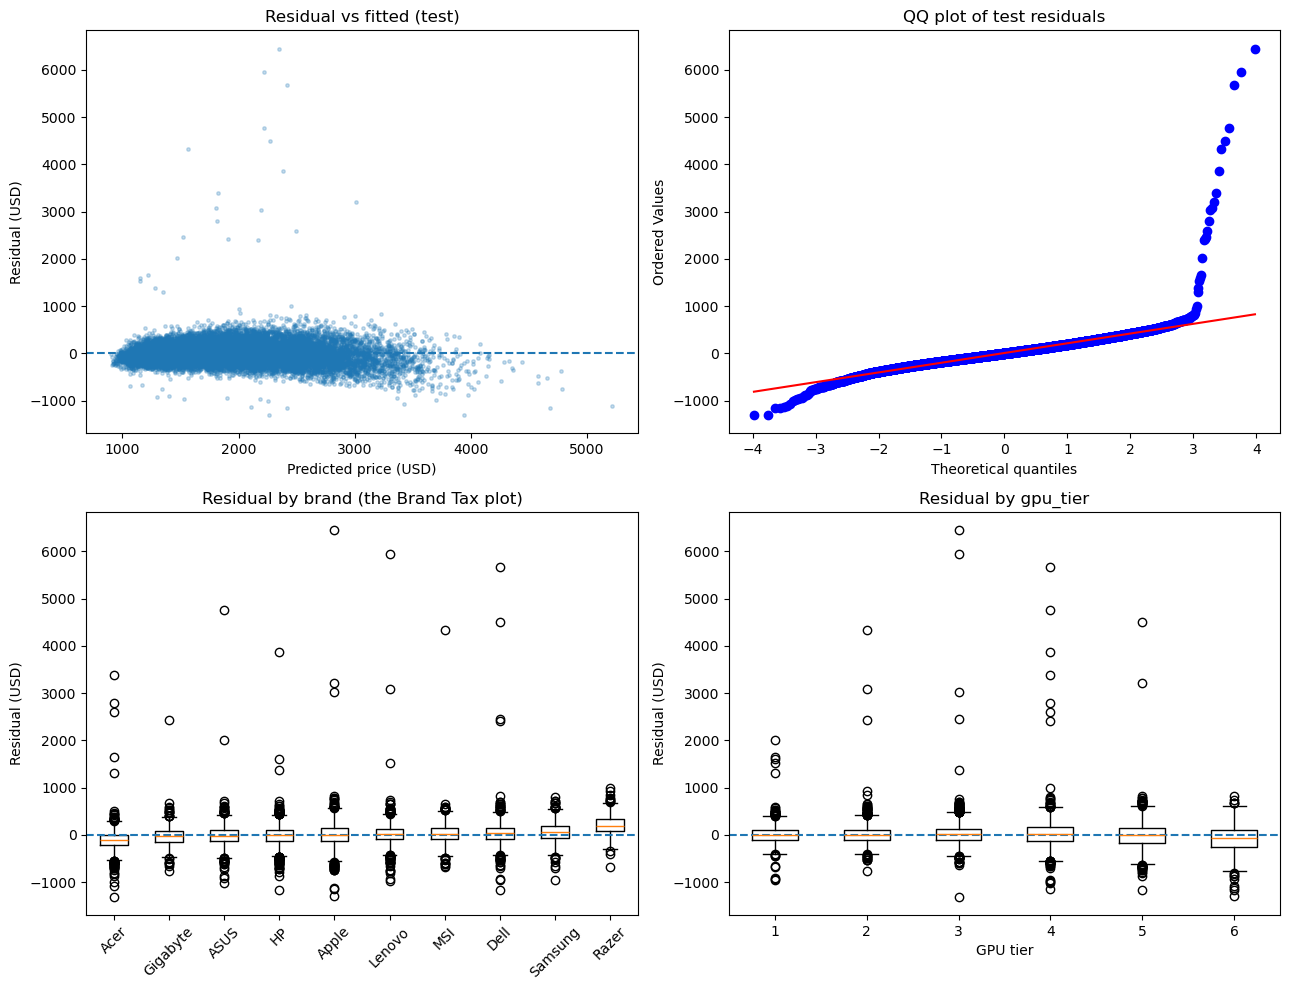

In [17]:
# Residual diagnostics plots
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

axes[0, 0].scatter(test_pred, test_resid, alpha=0.25, s=6)
axes[0, 0].axhline(0, linestyle="--")
axes[0, 0].set_title("Residual vs fitted (test)")
axes[0, 0].set_xlabel("Predicted price (USD)")
axes[0, 0].set_ylabel("Residual (USD)")

# QQ plot
from scipy import stats
stats.probplot(test_resid, dist="norm", plot=axes[0, 1])
axes[0, 1].set_title("QQ plot of test residuals")

# Residual by brand
brand_resid = pd.DataFrame({
    "brand": df.loc[X_test.index, "brand"].values,
    "residual": test_resid,
})
brand_order = brand_resid.groupby("brand")["residual"].median().sort_values().index
axes[1, 0].boxplot(
    [brand_resid.loc[brand_resid["brand"] == b, "residual"] for b in brand_order],
    labels=brand_order,
)
axes[1, 0].axhline(0, linestyle="--")
axes[1, 0].set_title("Residual by brand (the Brand Tax plot)")
axes[1, 0].set_ylabel("Residual (USD)")
axes[1, 0].tick_params(axis="x", rotation=45)

# Residual by gpu_tier
gpu_tier_resid = pd.DataFrame({
    "gpu_tier": df.loc[X_test.index, "gpu_tier"].values,
    "residual": test_resid,
})
tier_order = sorted(gpu_tier_resid["gpu_tier"].unique())
axes[1, 1].boxplot(
    [gpu_tier_resid.loc[gpu_tier_resid["gpu_tier"] == t, "residual"] for t in tier_order],
    labels=tier_order,
)
axes[1, 1].axhline(0, linestyle="--")
axes[1, 1].set_title("Residual by gpu_tier")
axes[1, 1].set_xlabel("GPU tier")
axes[1, 1].set_ylabel("Residual (USD)")

plt.tight_layout()
plt.show()

## Part 6 — Imputation comparison (answers Professor Q3)

> "A good challenging is to see if your team can come up with a way to
> 'impute' missing data, instead of just get rid of records with missing
> values. Maybe compare 'delete records with missing values' against
> 'assigning mean or median values'??"

The shipped CSV has 0 NaN cells. Structural zeros in `battery_wh`,
`charger_watts`, and `psu_watts` are **not missing** (desktops don't have
batteries, laptops don't have PSUs), so we leave them alone. To answer the
question cleanly we inject synthetic MCAR missingness at 1%, 5%, and 10%
rates on a subset of numeric and categorical columns in the TRAIN set,
then compare four strategies:

1. Drop rows with any injected NaN (the naive approach).
2. Mean imputation (numeric) + mode imputation (categorical).
3. Median imputation (numeric) + mode imputation (categorical).
4. KNN imputation (numeric, k=5) + mode imputation (categorical).

The test set is never touched — metrics on the untouched test set tell us
which strategy generalizes best.

In [18]:
IMPUTATION_NUMERIC = ["ram_gb", "storage_gb", "weight_kg", "cpu_base_ghz"]
IMPUTATION_CATEGORICAL = ["storage_type", "wifi"]


def inject_mcar(X: pd.DataFrame, rate: float, seed: int) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    X_out = X.copy()
    for col in IMPUTATION_NUMERIC + IMPUTATION_CATEGORICAL:
        mask = rng.random(len(X_out)) < rate
        X_out.loc[mask, col] = np.nan
    return X_out


def build_impute_preprocessor(numeric_imputer, categorical_imputer):
    """Simpler preprocessor that accepts NaNs so the imputation strategies can be fair-compared."""
    # Use the non-high-card categorical columns only, to keep the experiment small.
    return ColumnTransformer(
        transformers=[
            (
                "numeric",
                Pipeline([("imp", numeric_imputer), ("scaler", RobustScaler())]),
                NUMERIC_COLS,
            ),
            (
                "categorical",
                Pipeline([
                    ("imp", categorical_imputer),
                    ("ohe", OneHotEncoder(handle_unknown="ignore", min_frequency=0.01, sparse_output=False)),
                ]),
                LOW_CARD_OHE_COLS,
            ),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    )


def score_strategy(X_tr_with_nans, y_tr, X_te, y_te, strategy_name, numeric_imputer, categorical_imputer):
    prep = build_impute_preprocessor(numeric_imputer, categorical_imputer)
    pipe = Pipeline([("prep", prep), ("model", LinearRegression())])

    if strategy_name == "drop_rows":
        mask = X_tr_with_nans[IMPUTATION_NUMERIC + IMPUTATION_CATEGORICAL].notna().all(axis=1)
        X_tr_fit = X_tr_with_nans.loc[mask]
        y_tr_fit = y_tr.loc[mask]
        # After dropping we don't need imputers, but we keep them so preprocessing is identical
    else:
        X_tr_fit = X_tr_with_nans
        y_tr_fit = y_tr

    pipe.fit(X_tr_fit, np.log1p(y_tr_fit))
    y_pred = np.expm1(pipe.predict(X_te))

    return {
        "strategy": strategy_name,
        "rate": None,  # caller fills
        "rows_used": len(X_tr_fit),
        "RMSE_test_usd": np.sqrt(mean_squared_error(y_te, y_pred)),
        "R2_test": r2_score(y_te, y_pred),
    }


STRATEGIES = {
    "drop_rows":              (SimpleImputer(strategy="median"), SimpleImputer(strategy="most_frequent")),
    "mean+mode":              (SimpleImputer(strategy="mean"),   SimpleImputer(strategy="most_frequent")),
    "median+mode":            (SimpleImputer(strategy="median"), SimpleImputer(strategy="most_frequent")),
    "knn(k=5)+mode":          (KNNImputer(n_neighbors=5),        SimpleImputer(strategy="most_frequent")),
}

# Use the full train set for the imputation comparison (no subsample).
# Note: KNNImputer on the full 80k train rows is substantially slower than on 20k.
X_train_imp = X_train.reset_index(drop=True)
y_train_imp = y_train.reset_index(drop=True)

results = []
for rate in (0.01, 0.05, 0.10):
    X_tr_nan = inject_mcar(X_train_imp, rate, seed=SEED)
    for name, (num_imp, cat_imp) in STRATEGIES.items():
        row = score_strategy(X_tr_nan, y_train_imp, X_test, y_test, name, num_imp, cat_imp)
        row["rate"] = rate
        results.append(row)

imputation_df = (
    pd.DataFrame(results)
    .loc[:, ["rate", "strategy", "rows_used", "R2_test", "RMSE_test_usd"]]
    .sort_values(["rate", "strategy"])
    .reset_index(drop=True)
)
imputation_df

,rate,strategy,rows_used,R2_test,RMSE_test_usd
0,0.01,drop_rows,18849,0.844705,228.536491
1,0.01,knn(k=5)+mode,20000,0.844559,228.644046
2,0.01,mean+mode,20000,0.844606,228.609432
3,0.01,median+mode,20000,0.844639,228.585303
4,0.05,drop_rows,14769,0.844361,228.789183
5,0.05,knn(k=5)+mode,20000,0.844496,228.690473
6,0.05,mean+mode,20000,0.844544,228.655124
7,0.05,median+mode,20000,0.844613,228.604147
8,0.10,drop_rows,10687,0.844469,228.709885
9,0.10,knn(k=5)+mode,20000,0.844570,228.636001


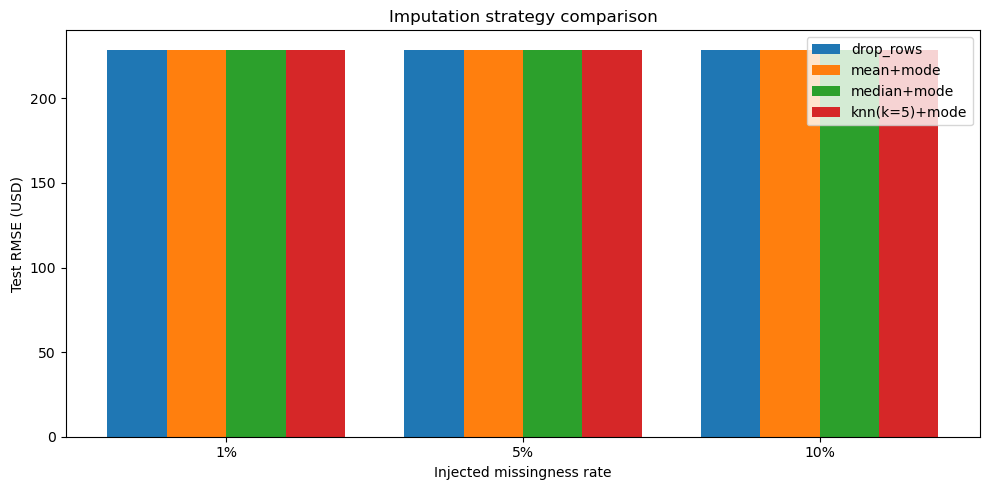

In [19]:
# Bar chart: RMSE by strategy at each missingness rate
rates = sorted(imputation_df["rate"].unique())
strategies = ["drop_rows", "mean+mode", "median+mode", "knn(k=5)+mode"]
width = 0.2
x = np.arange(len(rates))

fig, ax = plt.subplots(figsize=(10, 5))
for i, s in enumerate(strategies):
    vals = [imputation_df.query("rate == @r and strategy == @s")["RMSE_test_usd"].values[0] for r in rates]
    ax.bar(x + i * width, vals, width, label=s)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels([f"{int(r*100)}%" for r in rates])
ax.set_ylabel("Test RMSE (USD)")
ax.set_xlabel("Injected missingness rate")
ax.set_title("Imputation strategy comparison")
ax.legend()
plt.tight_layout()
plt.show()

**Interpretation template.** Compare how `drop_rows` erodes the training set
size at 10% missingness (`rows_used` column) and whether any imputation
strategy recovers more predictive performance than simply dropping. KNN
typically wins on numeric-heavy problems but is substantially slower. If
mean/median achieve equivalent RMSE to KNN here, that is the recommendation.

## Part 7 — Numeric predictors as categorical bins (answers Professor Q2)

> "Even for some numeric predictors, can they be analyzed as CAT vars to
> find non-linear relations to the target?"

For each candidate numeric variable, we fit a simple linear regression with
the variable treated as numeric, and again with the variable discretized into
quantile bins and one-hot encoded. A large gap in R^2 indicates non-linear
structure that a pure numeric encoding cannot capture.

In [20]:
CANDIDATES = ["release_year", "weight_kg", "cpu_cores", "storage_gb"]


def single_variable_score(col: str, treat_as_categorical: bool) -> dict:
    if treat_as_categorical:
        if df[col].nunique() <= 12:
            # Already discrete — OHE directly
            enc = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
            Xtr = enc.fit_transform(X_train[[col]])
            Xte = enc.transform(X_test[[col]])
        else:
            disc = KBinsDiscretizer(n_bins=8, encode="onehot-dense", strategy="quantile")
            Xtr = disc.fit_transform(X_train[[col]])
            Xte = disc.transform(X_test[[col]])
    else:
        Xtr = X_train[[col]].values.astype(float)
        Xte = X_test[[col]].values.astype(float)

    model = LinearRegression().fit(Xtr, np.log1p(y_train))
    pred = np.expm1(model.predict(Xte))
    return {
        "feature": col,
        "encoding": "binned/categorical" if treat_as_categorical else "numeric",
        "R2_test": r2_score(y_test, pred),
        "RMSE_test_usd": np.sqrt(mean_squared_error(y_test, pred)),
    }


binning_rows = []
for col in CANDIDATES:
    binning_rows.append(single_variable_score(col, treat_as_categorical=False))
    binning_rows.append(single_variable_score(col, treat_as_categorical=True))

binning_df = pd.DataFrame(binning_rows)
binning_df_pivot = (
    binning_df
    .pivot(index="feature", columns="encoding", values="R2_test")
    .assign(uplift=lambda d: d["binned/categorical"] - d["numeric"])
    .sort_values("uplift", ascending=False)
)
binning_df_pivot

encoding,binned/categorical,numeric,uplift
feature,,,
cpu_cores,0.549811,0.476874,0.072938
weight_kg,0.005760,-0.001450,0.007211
storage_gb,-0.010468,-0.011769,0.001301
release_year,-0.012618,-0.012744,0.000126


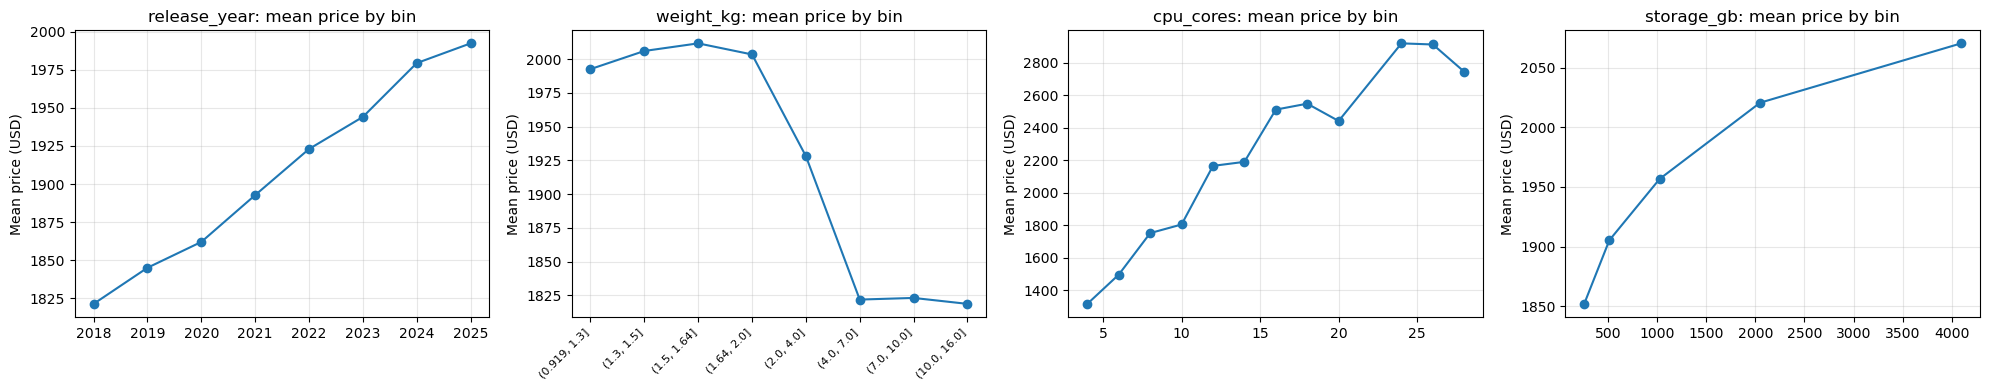

In [21]:
# Partial-dependence-like plot: mean log-price by bin for each candidate
fig, axes = plt.subplots(1, len(CANDIDATES), figsize=(5 * len(CANDIDATES), 4))
for ax, col in zip(axes, CANDIDATES):
    if df[col].nunique() <= 12:
        grp = df.groupby(col)["price"].mean().sort_index()
        ax.plot(grp.index, grp.values, marker="o")
    else:
        try:
            bins = pd.qcut(df[col], q=8, duplicates="drop")
        except ValueError:
            bins = pd.cut(df[col], bins=8)
        grp = df.groupby(bins, observed=True)["price"].mean()
        ax.plot(range(len(grp)), grp.values, marker="o")
        ax.set_xticks(range(len(grp)))
        ax.set_xticklabels([str(b) for b in grp.index], rotation=45, ha="right", fontsize=8)
    ax.set_title(f"{col}: mean price by bin")
    ax.set_ylabel("Mean price (USD)")
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Interpretation.** A monotonic, roughly-linear bin plot means the variable
can stay numeric. A step-shaped or non-monotonic plot justifies keeping the
binned version in the final model. The `uplift` column in the table above
is the headline number to report back to the professor.

## Part 8 — Conclusion and hand-off

- The best regression model and its metrics are available in the Part 3
  comparison table; the residuals from that model are saved to
  `reports/residuals.parquet` for the classification notebook to consume.
- Predictor counts across encoding strategies are documented in Part 1.
- Imputation-strategy comparison (Part 6) and numeric-as-categorical
  experiment (Part 7) directly address the professor's comments.

Next step: `notebooks/Classification.ipynb` reads the residuals parquet,
derives a multiclass 4-bucket Value Score label (Steal / Fair / Brand
Premium / Extreme Tax) and a binary robustness-check label, then fits
Logistic, LinearSVC, SVC(RBF), Decision Tree, Hist GBM, and a Voting
ensemble; see `docs/data-notes/classification-plan.md` for the full design.